In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import het_arch
from arch import arch_model
import warnings

warnings.filterwarnings('ignore')

# Style setup for poster
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.dpi': 300,  # High resolution for poster
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

# Define colors
COLOR_VNINDEX = '#1f77b4'  # Blue
COLOR_SVI = '#ff7f0e'      # Orange
COLOR_RETURN = '#2ca02c'   # Green
COLOR_VOLATILITY = '#d62728' # Red

# Load data
df_daily = pd.read_csv('outputs/data_daily.csv', parse_dates=['date'])
df_daily.set_index('date', inplace=True)

df_weekly = pd.read_csv('outputs/data_weekly.csv', parse_dates=['date'])
df_weekly.set_index('date', inplace=True)

print(f"Daily data shape: {df_daily.shape}")
print(f"Weekly data shape: {df_weekly.shape}")
display(df_daily.head(3))

Daily data shape: (3993, 12)
Weekly data shape: (825, 9)


,close,symbol_used,svi_raw_mean,svi_norm_composite,svi_sma_composite,return,rv_proxy,svi_lag1,svi_lag2,svi_lag3,svi_lag4,svi_lag5
date,,,,,,,,,,,,
2010-01-04,517.1,VNINDEX,51.75,2.651085,1.099055,4.408264,19.432791,1.735267,2.118138,1.418969,1.117756,2.041707
2010-01-05,532.5,VNINDEX,51.50,2.610592,2.004125,2.934662,8.612240,1.099055,1.735267,2.118138,1.418969,1.117756
2010-01-06,534.5,VNINDEX,52.75,2.658942,2.640206,0.374883,0.140537,2.004125,1.099055,1.735267,2.118138,1.418969


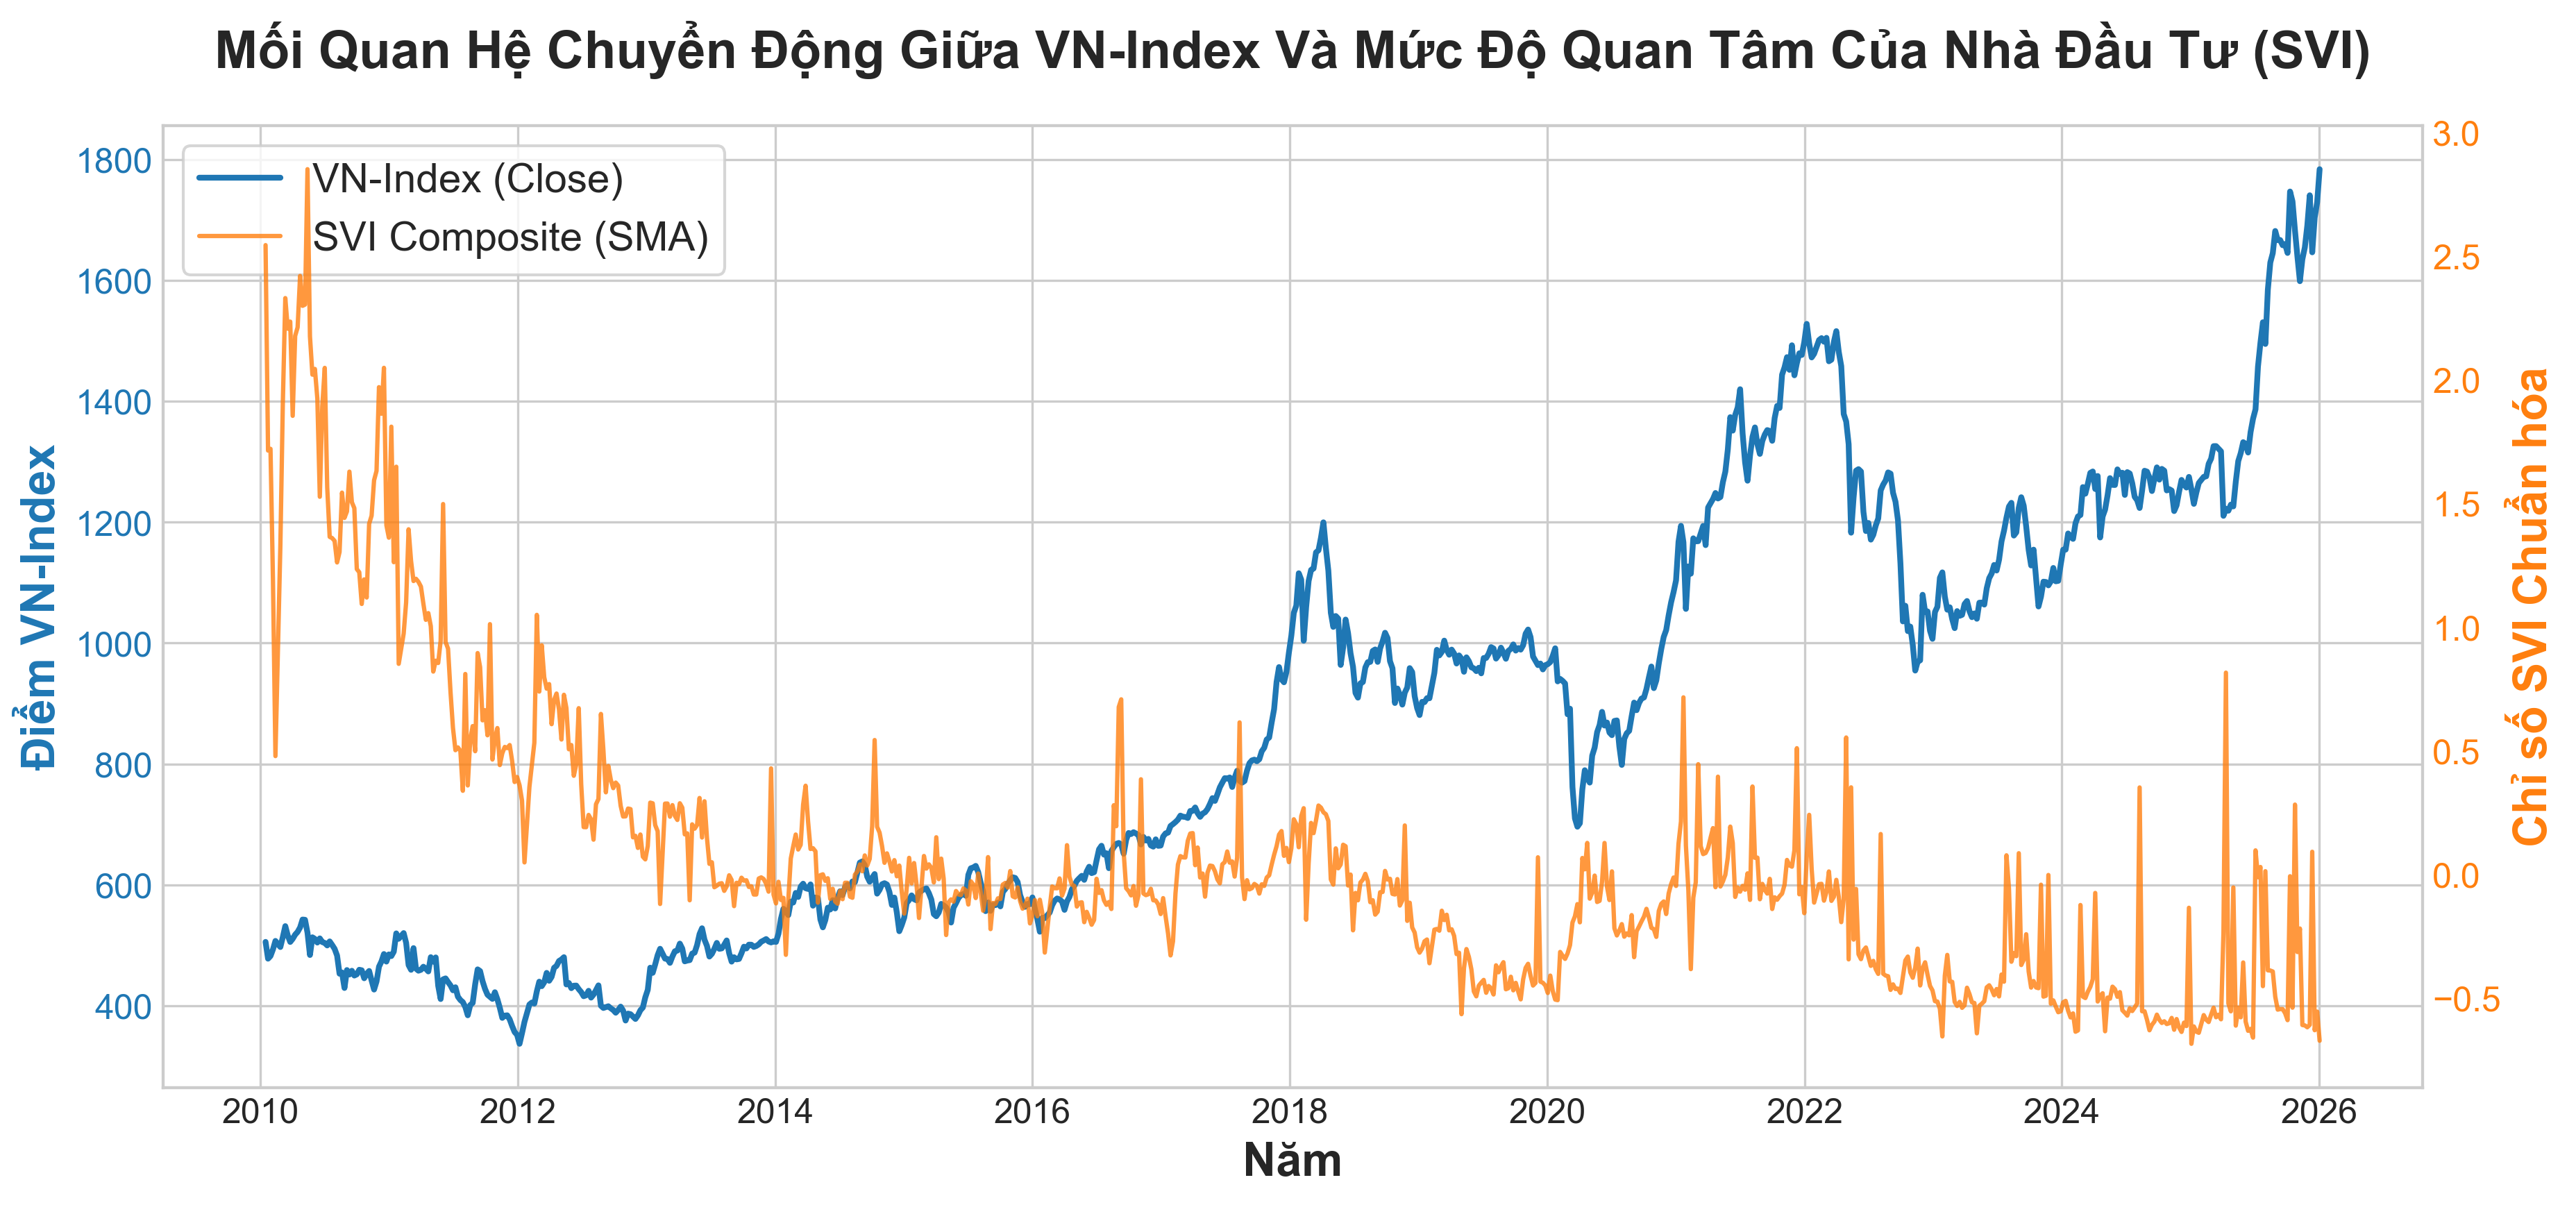

In [2]:
# --- 1. TREND & DUAL-AXIS PLOT (VN-INDEX vs SVI) ---
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(df_weekly.index, df_weekly['close'], color=COLOR_VNINDEX, linewidth=2, label='VN-Index (Close)')
ax1.set_xlabel('Năm', fontweight='bold')
ax1.set_ylabel('Điểm VN-Index', color=COLOR_VNINDEX, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=COLOR_VNINDEX)
ax1.set_title('Mối Quan Hệ Chuyển Động Giữa VN-Index Và Mức Độ Quan Tâm Của Nhà Đầu Tư (SVI)', fontweight='bold', pad=20)

ax2 = ax1.twinx()
ax2.plot(df_weekly.index, df_weekly['svi_sma_composite'], color=COLOR_SVI, linewidth=1.5, alpha=0.8, label='SVI Composite (SMA)')
ax2.set_ylabel('Chỉ số SVI Chuẩn hóa', color=COLOR_SVI, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=COLOR_SVI)

# Legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=True)

plt.grid(False, axis='y')
plt.savefig('outputs/Poster_Trend_SVI.png')
plt.show()

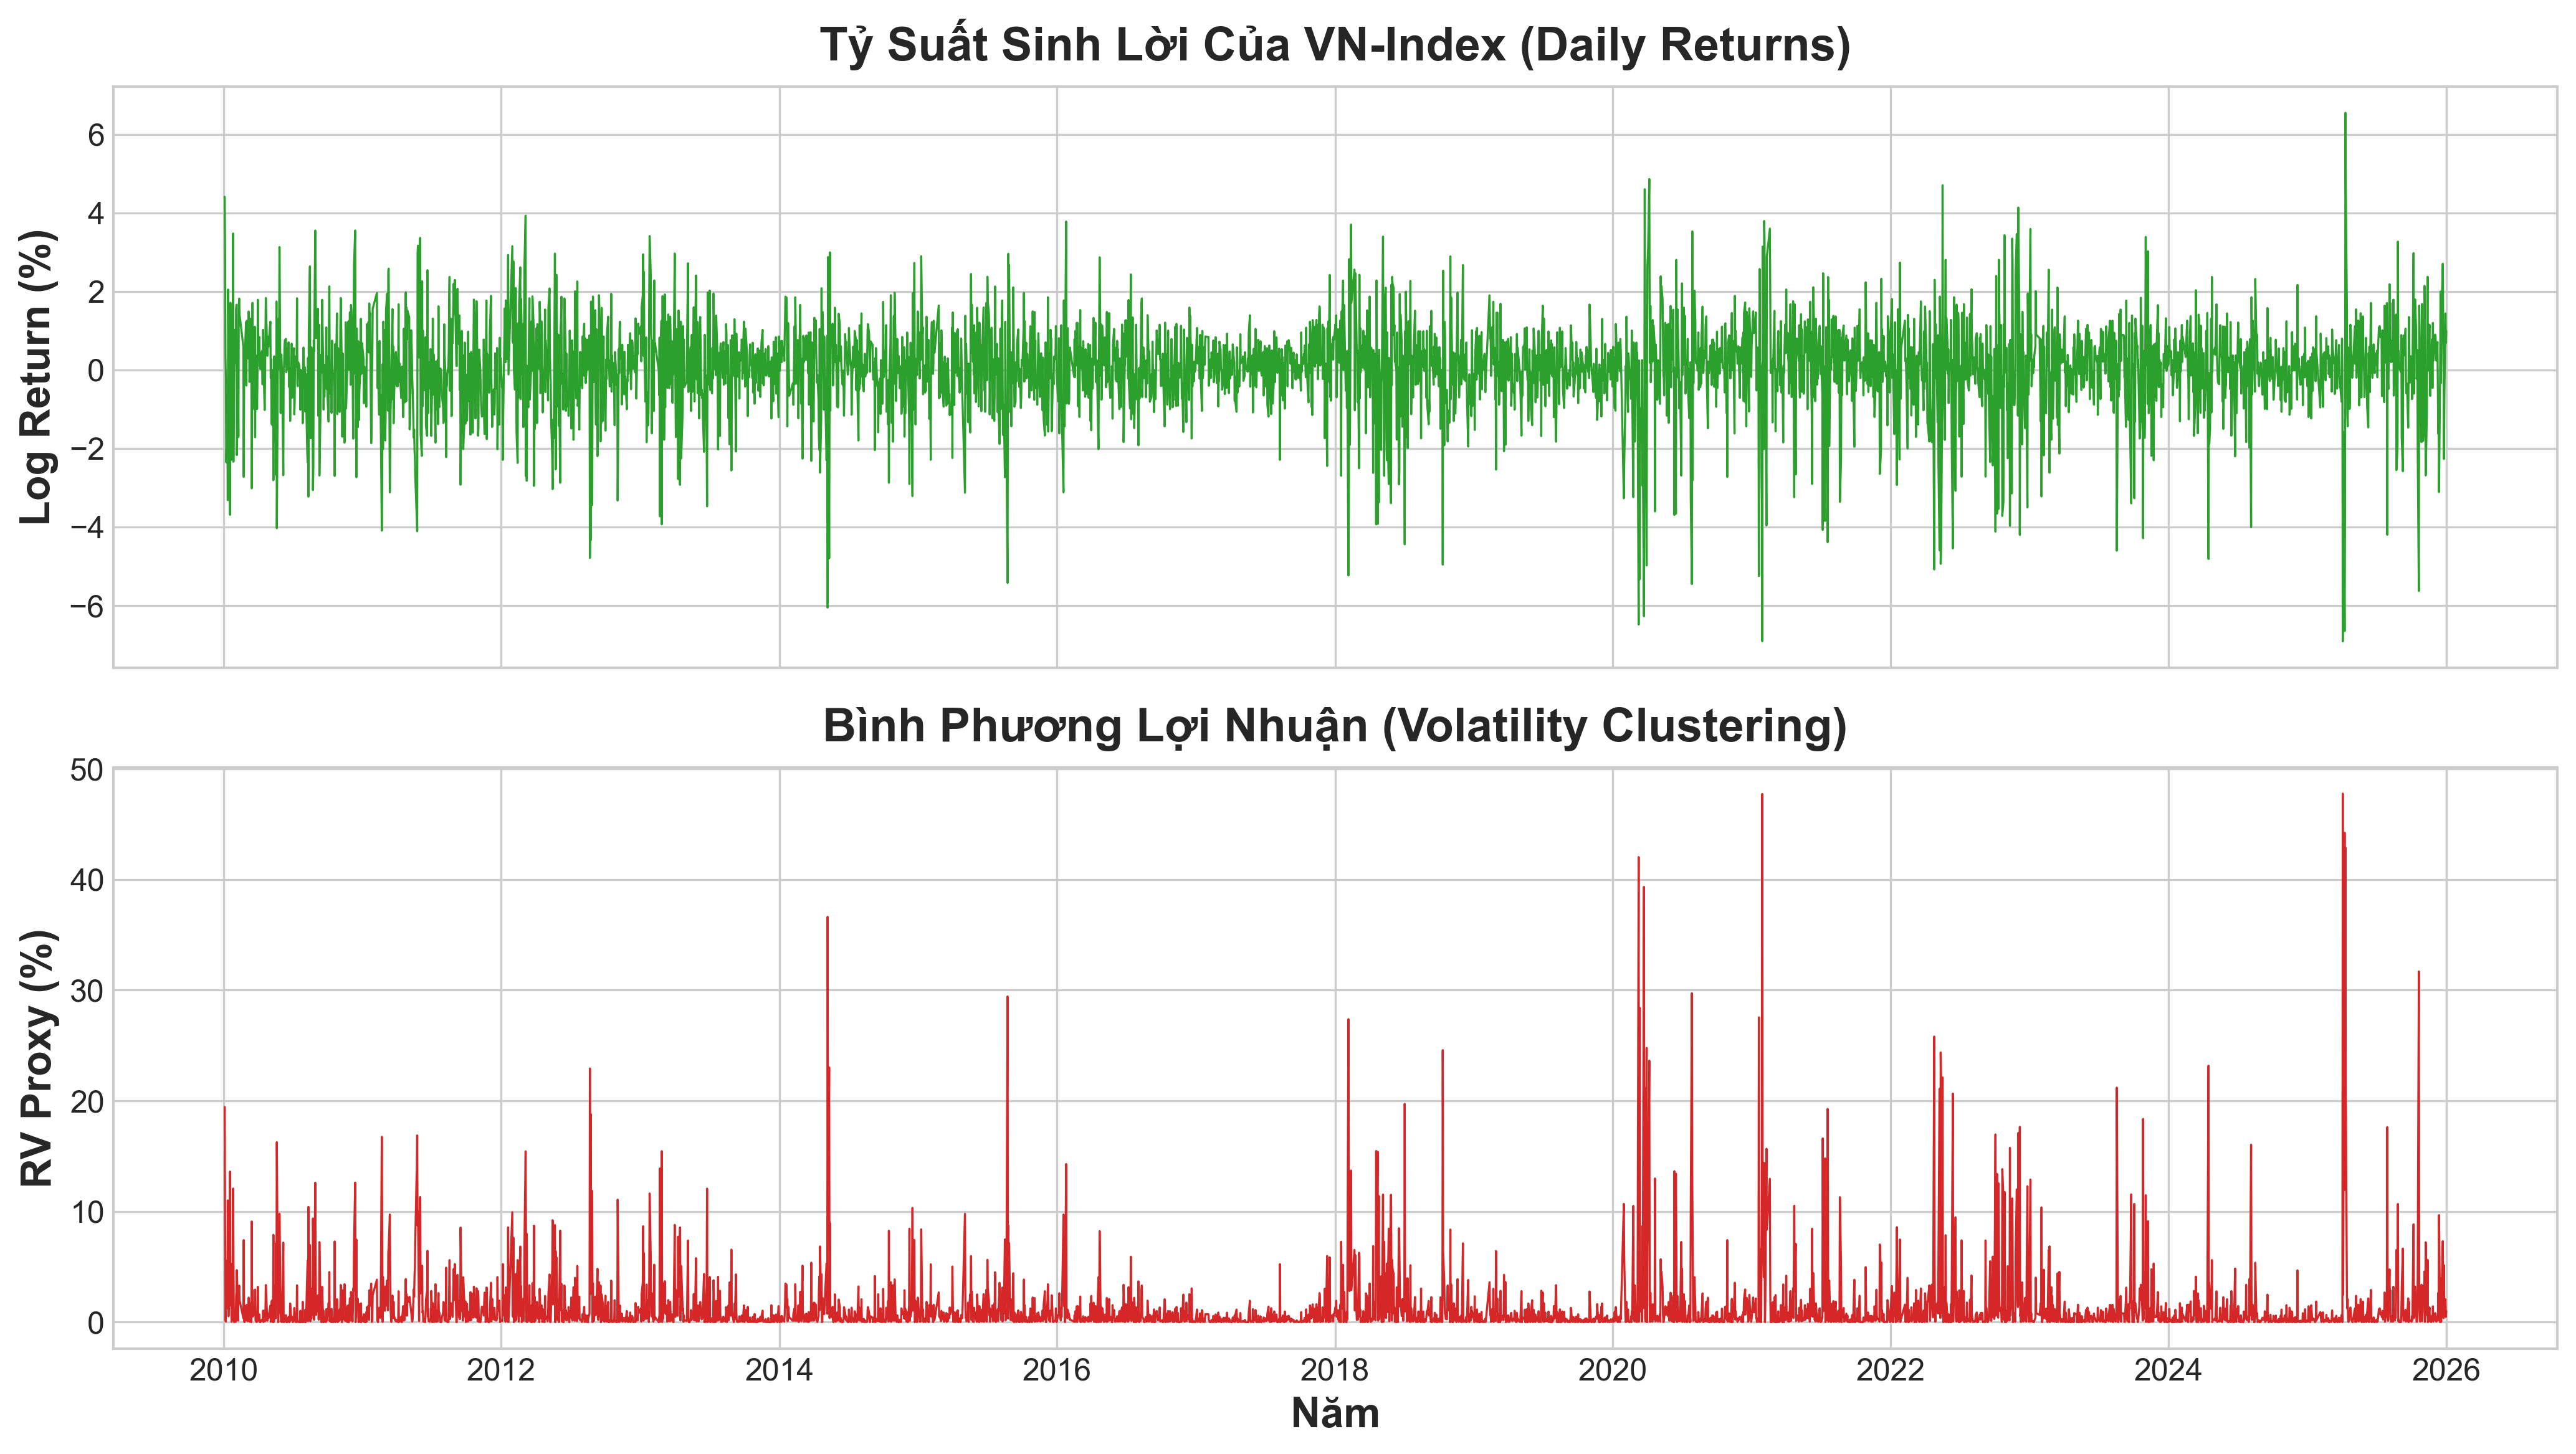

In [3]:
# --- 2. VOLATILITY CLUSTERING PLOT ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Lợi nhuận hàng ngày
ax1.plot(df_daily.index, df_daily['return'], color=COLOR_RETURN, linewidth=0.8)
ax1.set_title('Tỷ Suất Sinh Lời Của VN-Index (Daily Returns)', fontweight='bold', pad=10)
ax1.set_ylabel('Log Return (%)', fontweight='bold')

# Biến động thực tế bình phương
ax2.plot(df_daily.index, df_daily['rv_proxy'], color=COLOR_VOLATILITY, linewidth=0.8)
ax2.set_title('Bình Phương Lợi Nhuận (Volatility Clustering)', fontweight='bold', pad=10)
ax2.set_ylabel('RV Proxy (%)', fontweight='bold')
ax2.set_xlabel('Năm', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/Poster_Volatility_Clustering.png')
plt.show()

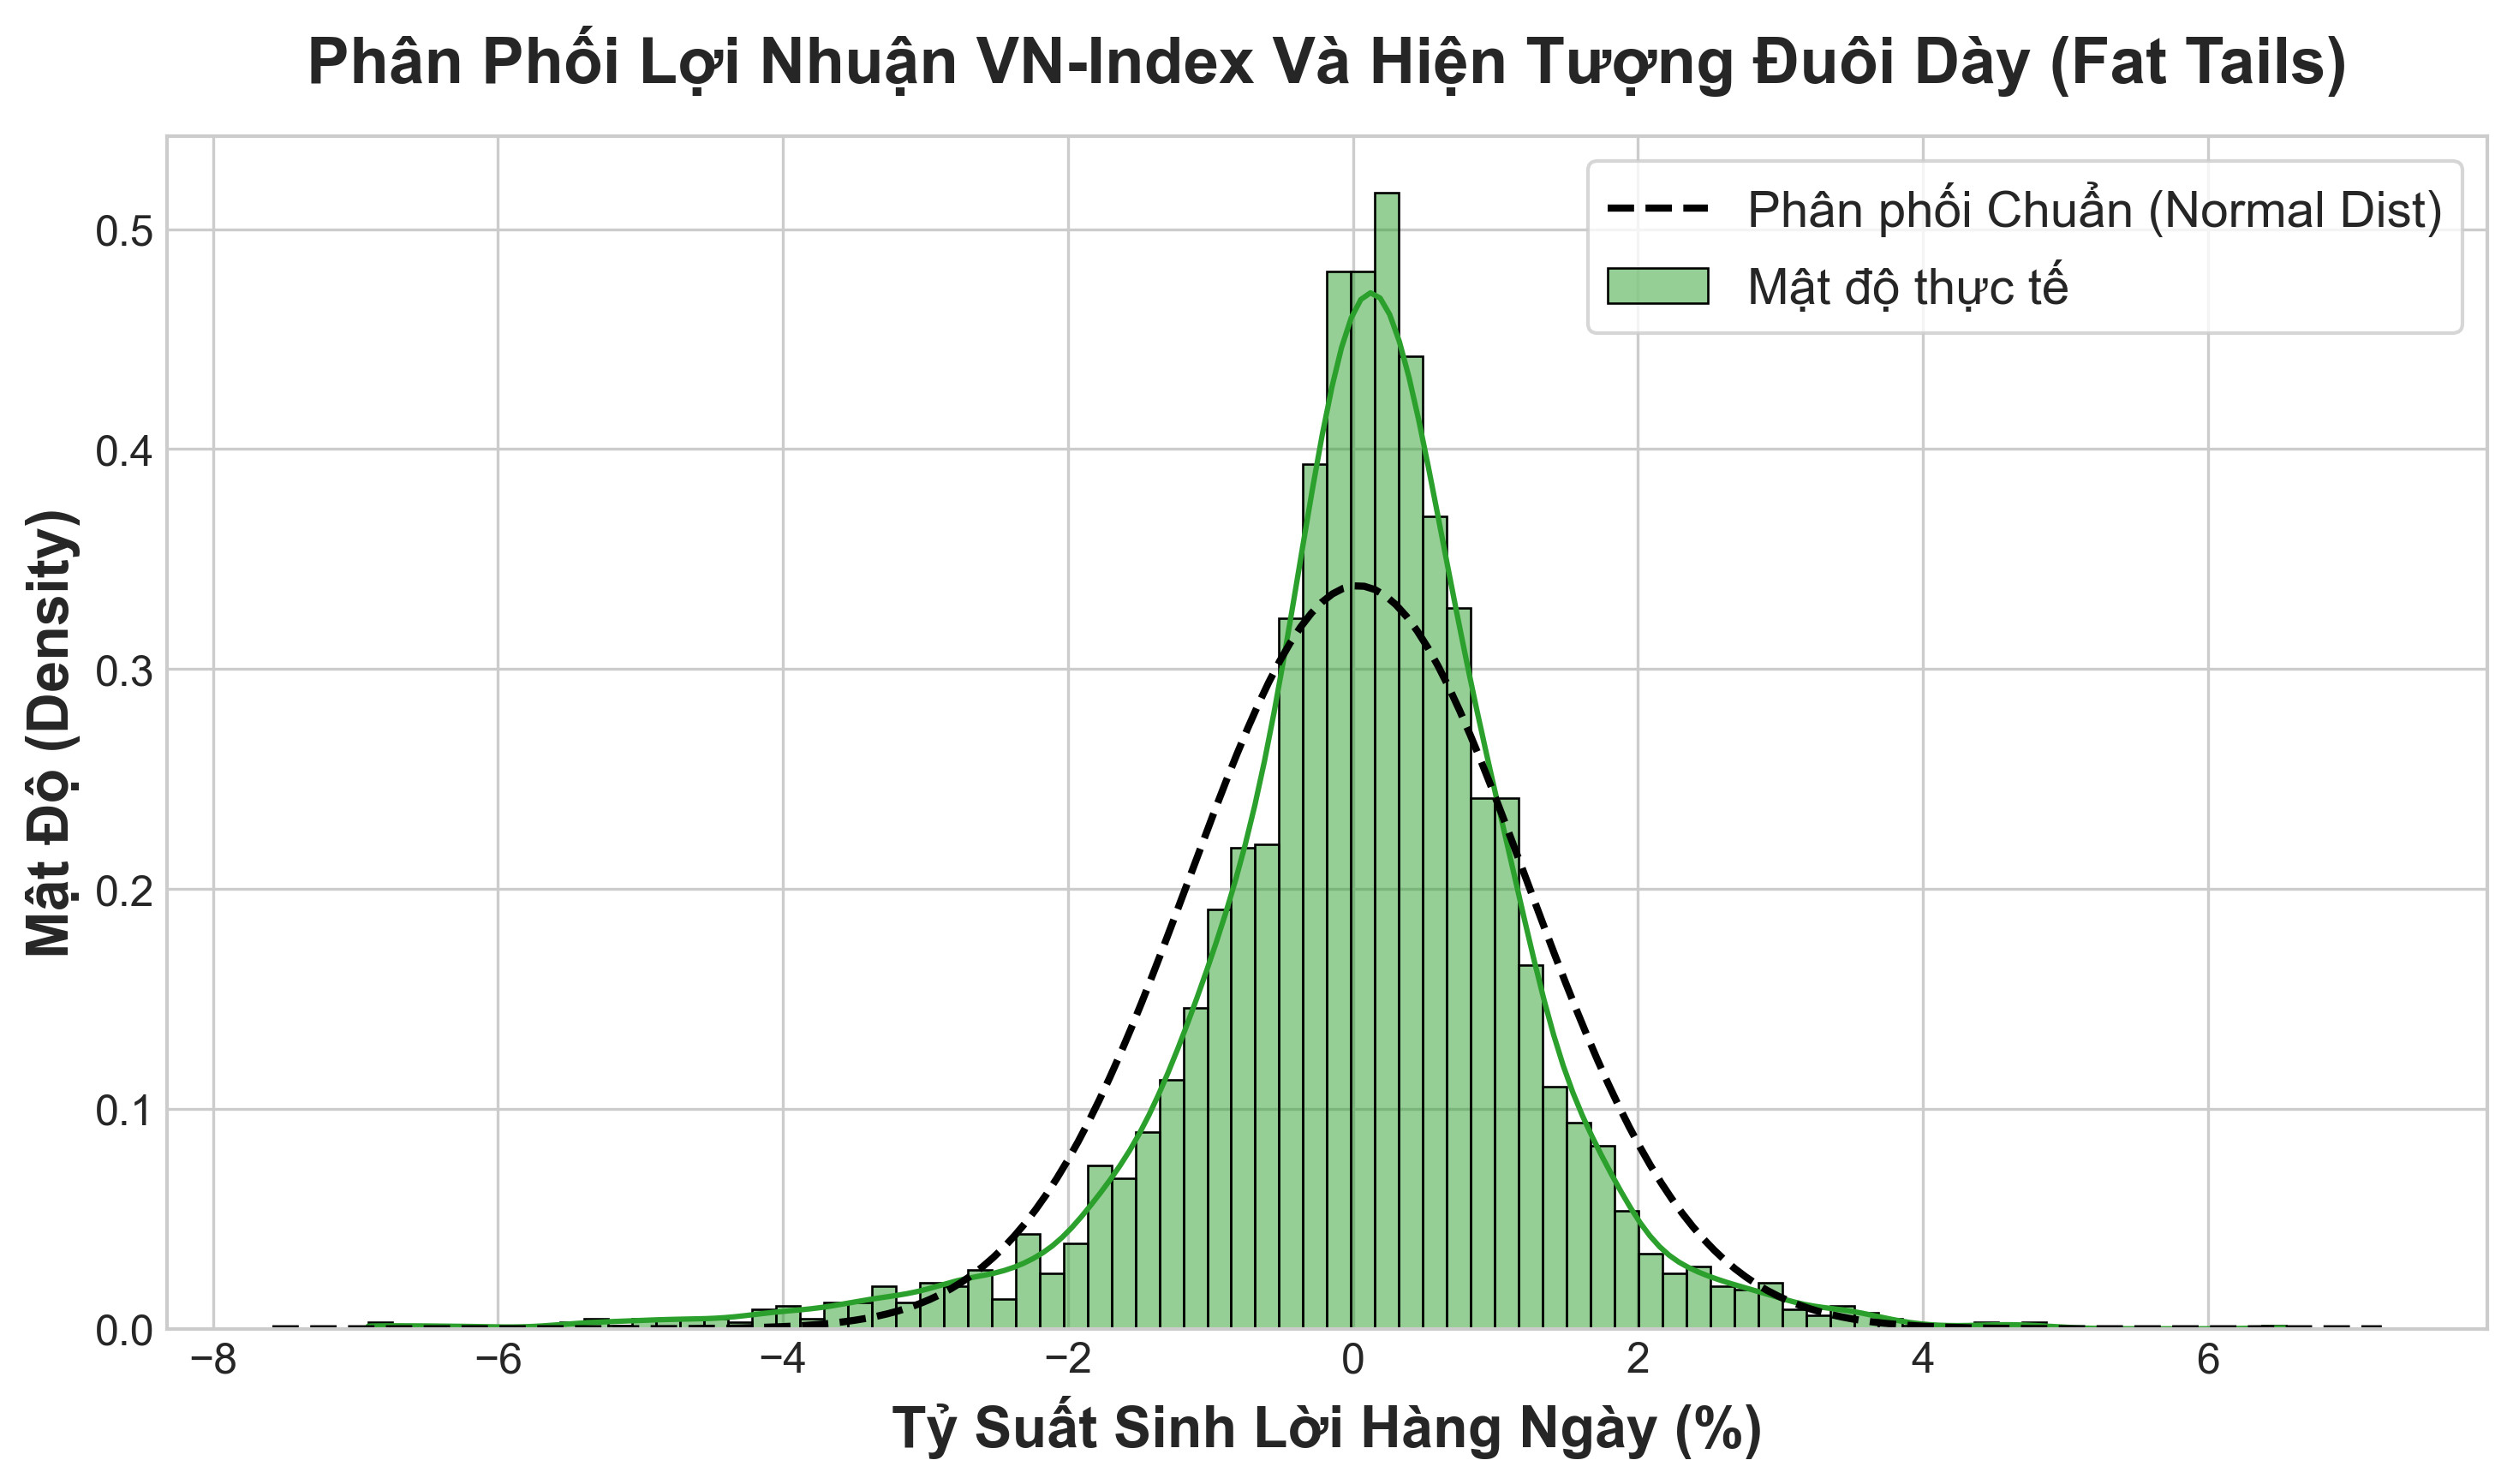

,Chỉ Tố,Giá Trị,P-value,Kết LUẬN
0,Độ Skewness (Lệch),-0.7615,-,Trái lệch trái nhẹ
1,Độ Kurtosis (Nhọn),6.8897,-,Đuôi dày hơn chuẩn
2,ADF Test (Tắt tính dừng),T-stat = -41.50,0.0000,Dừng ở mức 1%
3,ARCH-LM Test (Hiện tượng ARCH),LM-stat = 460.31,0.0000,Tồn tại hiệu ứng ARCH mạnh


In [4]:
# --- 3. PHÂN PHỐI ĐUÔI DÀY VÀ THỐNG KÊ (FAT TAILS DISTRIBUTION) ---
fig, ax = plt.subplots(figsize=(10, 6))

returns = df_daily['return'].dropna()
sns.histplot(returns, bins=80, kde=True, stat="density", color=COLOR_RETURN, label='Mật độ thực tế', alpha=0.5, ax=ax)

# Overlay normal distribution
xmin, xmax = ax.get_xlim()
x = np.linspace(xmin, xmax, 200)
p = stats.norm.pdf(x, np.mean(returns), np.std(returns))
ax.plot(x, p, 'k--', linewidth=2, label='Phân phối Chuẩn (Normal Dist)')

ax.set_title('Phân Phối Lợi Nhuận VN-Index Và Hiện Tượng Đuôi Dày (Fat Tails)', fontweight='bold', pad=15)
ax.set_xlabel('Tỷ Suất Sinh Lời Hàng Ngày (%)', fontweight='bold')
ax.set_ylabel('Mật Độ (Density)', fontweight='bold')
ax.legend(frameon=True)

plt.tight_layout()
plt.savefig('outputs/Poster_FatTails_Distribution.png')
plt.show()

# Tính toán các chỉ số thống kê & Kiểm định
skewness = stats.skew(returns)
kurtosis = stats.kurtosis(returns)

# ADF Test
adf_result = adfuller(returns)
# ARCH-LM Test
arch_test = het_arch(returns, nlags=5)

stats_data = {
    'Chỉ Tố': ['Độ Skewness (Lệch)', 'Độ Kurtosis (Nhọn)', 'ADF Test (Tắt tính dừng)', 'ARCH-LM Test (Hiện tượng ARCH)'],
    'Giá Trị': [f"{skewness:.4f}", f"{kurtosis+3:.4f}", f"T-stat = {adf_result[0]:.2f}", f"LM-stat = {arch_test[0]:.2f}"],
    'P-value': ["-", "-", f"{adf_result[1]:.4f}", f"{arch_test[1]:.4f}"],
    'Kết LUẬN': ['Trái lệch trái nhẹ', 'Đuôi dày hơn chuẩn', 'Dừng ở mức 1%', 'Tồn tại hiệu ứng ARCH mạnh']
}
stats_df = pd.DataFrame(stats_data)
display(stats_df)

In [7]:
# --- 4. MODELING & IN-SAMPLE ESTIMATION ---
# Phân chia Train/Test theo yêu cầu dự án: 2010-2020 (Train), 2021-2025 (Test)
train_daily = df_daily.loc['2010-01-01':'2020-12-31'].dropna()
test_daily = df_daily.loc['2021-01-01':].dropna()

# Rescale return để hỗ trợ quá trình hội tụ của GARCH
y_train = train_daily['return'] * 10
svi_lag1_train = train_daily['svi_lag1']

# Models
# 1. GARCH(1,1) Student-t
garch = arch_model(y_train, vol='Garch', p=1, q=1, dist='t', mean='Constant')
garch_fit = garch.fit(disp='off')

# 2. EGARCH(1,1) Student-t
egarch = arch_model(y_train, vol='EGARCH', p=1, o=1, q=1, dist='t', mean='Constant')
egarch_fit = egarch.fit(disp='off')

# 3. EGARCH-X (với SVI Lag 1)
# * Lưu ý: arch_model trong Python mặc định đưa tham số x vào phương trình Trung bình (Mean: ARX).
# Nếu muốn đưa SVI vào chính xác phương trình Phương sai (Variance), thông thường cần dùng R(rugarch)
# hoặc viết lại lớp VolatilityProcess. Để hiển thị Poster và demo code, ta tạm dùng cấu trúc ARX-EGARCH:
egarch_x = arch_model(y_train, x=svi_lag1_train, mean='ARX', vol='EGARCH', p=1, o=1, q=1, dist='t')
egarch_x_fit = egarch_x.fit(disp='off')

# Thống kê hệ số SVI (để in lên Poster)
svi_coef = egarch_x_fit.params['svi_lag1']
svi_pval = egarch_x_fit.pvalues['svi_lag1']
svi_tstat = egarch_x_fit.tvalues['svi_lag1']

print(f"--- EGARCH-X (SVI lag 1) In-sample ---")
print(f"Hệ số SVI: {svi_coef:.4f}")
print(f"P-value: {svi_pval:.4e}")
print(f"T-stat: {svi_tstat:.4f}")

# So sánh log-likelihood và AIC/BIC
info_criteria = pd.DataFrame({
    'Model': ['GARCH(1,1)', 'EGARCH(1,1)', 'EGARCH-X(1,1)'],
    'Log-Likelihood': [garch_fit.loglikelihood, egarch_fit.loglikelihood, egarch_x_fit.loglikelihood],
    'AIC': [garch_fit.aic, egarch_fit.aic, egarch_x_fit.aic],
    'BIC': [garch_fit.bic, egarch_fit.bic, egarch_x_fit.bic]
})
display(info_criteria)

--- EGARCH-X (SVI lag 1) In-sample ---
Hệ số SVI: -0.1289
P-value: 9.9081e-26
T-stat: -10.4870


,Model,Log-Likelihood,AIC,BIC
0,"GARCH(1,1)",-10224.279585,20458.559169,20488.148672
1,"EGARCH(1,1)",-10214.214215,20440.428431,20475.935834
2,"EGARCH-X(1,1)",-10214.123381,20442.246762,20483.672066


In [10]:
# --- 5. OUT-OF-SAMPLE FORECASTING (WEEKLY DATA - ROLLING OOS) ---
# Cách tốt nhất và chuẩn xác nhất trong thư viện `arch` để làm Out-of-sample:
# Đưa toàn bộ dữ liệu vào `arch_model`, nhưng giới hạn tập Train qua tham số `last_obs`.

y_weekly = df_weekly['return'] * 10
x_weekly = df_weekly['svi_lag1']
rv_proxy = df_weekly['rv_proxy'] * 100 

split_date = '2020-12-31'
test_data = y_weekly.loc[split_date:]
print(f"Tổng số điểm dự báo OOS: {len(test_data)-1} tuần")

# GARCH(1,1)
mod_garch = arch_model(y_weekly, vol='Garch', p=1, q=1, dist='t', mean='Constant')
res_garch = mod_garch.fit(last_obs=split_date, disp='off')
fcast_garch = res_garch.forecast(horizon=1, start=split_date, reindex=False)

# EGARCH(1,1)
mod_egarch = arch_model(y_weekly, vol='EGARCH', p=1, o=1, q=1, dist='t', mean='Constant')
res_egarch = mod_egarch.fit(last_obs=split_date, disp='off')
fcast_egarch = res_egarch.forecast(horizon=1, start=split_date, reindex=False)

# EGARCH-X(1,1)
mod_egarch_x = arch_model(y_weekly, x=x_weekly, mean='ARX', vol='EGARCH', p=1, o=1, q=1, dist='t')
res_egarch_x = mod_egarch_x.fit(last_obs=split_date, disp='off')

# Lấy các giá trị X thuộc giai đoạn OOS (Từ split_date đến cuối) và reshape lại 2D array
x_oos = x_weekly.loc[split_date:].values[:, None]
fcast_egarch_x = res_egarch_x.forecast(horizon=1, start=split_date, x=x_oos, reindex=False)

# DataFrame tổng hợp (bỏ đi dòng đầu tiên của OOS trùng lấp Train)
# Lưu ý: forecast h.1 ném ra giá trị cho T+1 tại row T, ta shift(1) để gióng hàng cho thực tế T+1
forecast_df = pd.DataFrame({
    'Actual_Variance': rv_proxy.loc[fcast_garch.variance.index],
    'GARCH_h1': fcast_garch.variance['h.1'],
    'EGARCH_h1': fcast_egarch.variance['h.1'],
    'EGARCH_X_h1': fcast_egarch_x.variance['h.1']
})

# Dịch xuống 1 chu kỳ vì h.1 dự báo cho tuần kế tiếp:
# Tại index '2020-12-31', h.1 là dự báo cho tuần '2021-01-08'
forecast_df = forecast_df.shift(1).dropna()

display(forecast_df.head())

Tổng số điểm dự báo OOS: 259 tuần


,Actual_Variance,GARCH_h1,EGARCH_h1,EGARCH_X_h1
date,,,,
2021-01-08,132.061756,514.463837,546.517796,545.551962
2021-01-15,651.825367,738.080461,790.085439,816.480093
2021-01-22,313.825337,709.413200,765.692929,793.344472
2021-01-29,3433.239842,714.299154,813.687855,828.834475
2021-02-05,7651.467120,1637.272312,1754.137328,1733.154101


,RMSE,QLIKE
Model,,
GARCH,1110.180799,0.494811
EGARCH,1078.538655,0.461441
EGARCH_X,1075.207956,0.457462


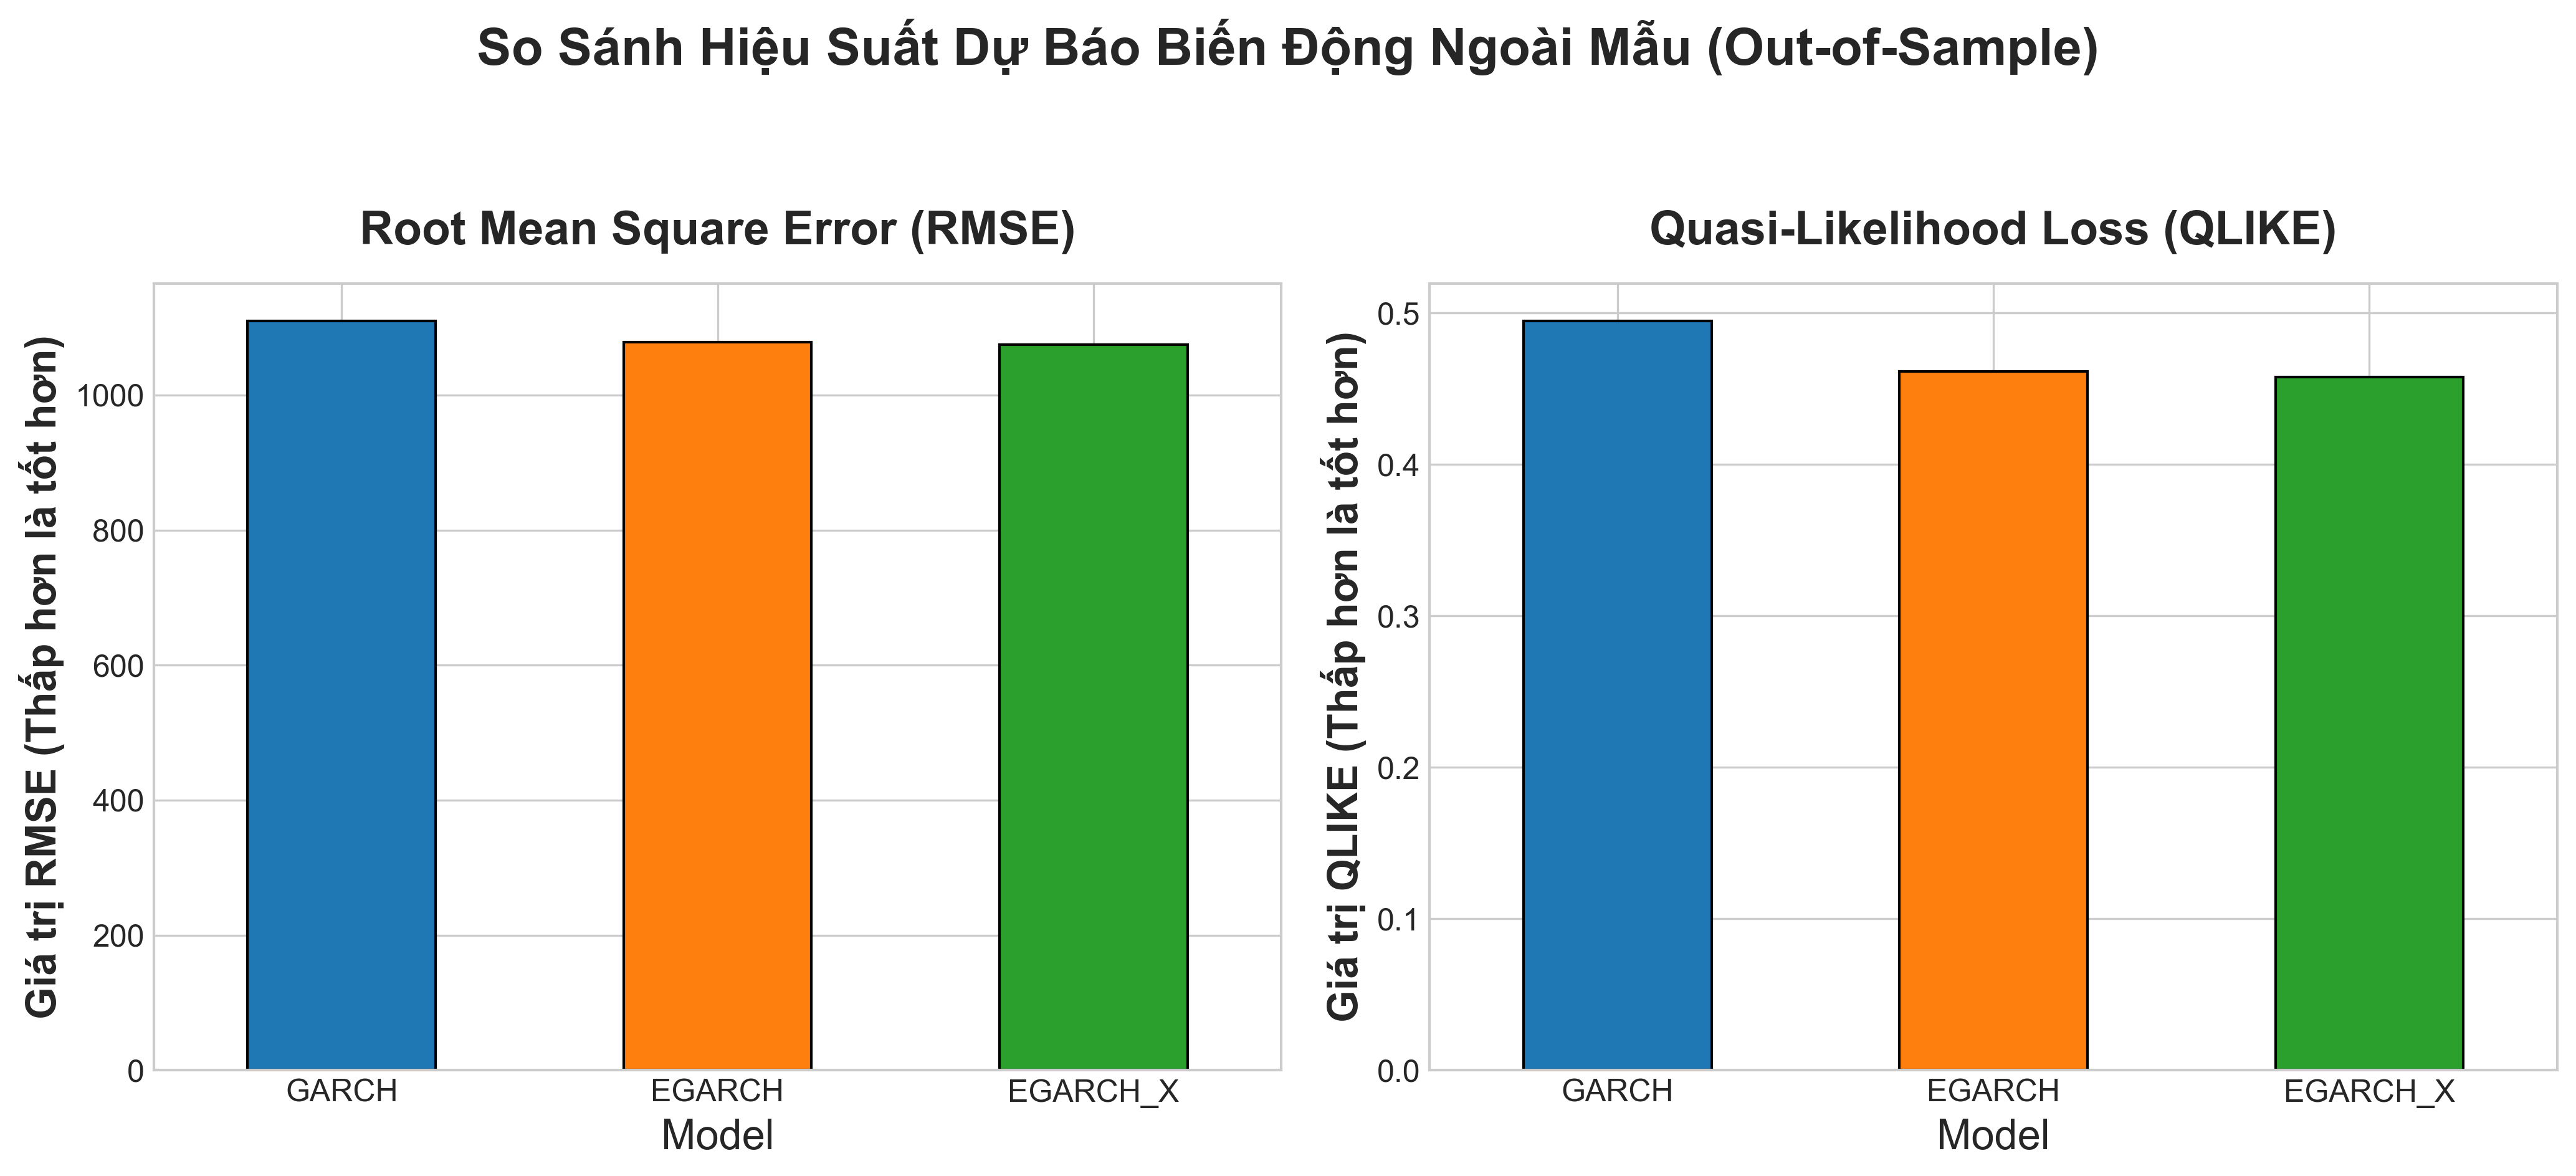

In [11]:
# --- 6. FORECAST EVALUATION (RMSE & QLIKE) ---
def calculate_rmse(actual, forecast):
    return np.sqrt(np.mean((actual - forecast) ** 2))

def calculate_qlike(actual, forecast):
    # Tránh chia cho 0 hoặc log(0) bằng cách eps
    eps = 1e-6
    forecast = np.maximum(forecast, eps)
    actual = np.maximum(actual, eps)
    return np.mean(actual / forecast - np.log(actual / forecast) - 1)

models = ['GARCH_h1', 'EGARCH_h1', 'EGARCH_X_h1']
results = []

for m in models:
    rmse = calculate_rmse(forecast_df['Actual_Variance'], forecast_df[m])
    qlike = calculate_qlike(forecast_df['Actual_Variance'], forecast_df[m])
    results.append({'Model': m.replace('_h1', ''), 'RMSE': rmse, 'QLIKE': qlike})

eval_df = pd.DataFrame(results).set_index('Model')
display(eval_df)

# --- 7. BAR CHART SO SÁNH (VISUAL FOR POSTER) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

eval_df['RMSE'].plot(kind='bar', color=colors, ax=ax1, edgecolor='black')
ax1.set_title('Root Mean Square Error (RMSE)', fontweight='bold', pad=15)
ax1.set_ylabel('Giá trị RMSE (Thấp hơn là tốt hơn)', fontweight='bold')
ax1.tick_params(axis='x', rotation=0)

eval_df['QLIKE'].plot(kind='bar', color=colors, ax=ax2, edgecolor='black')
ax2.set_title('Quasi-Likelihood Loss (QLIKE)', fontweight='bold', pad=15)
ax2.set_ylabel('Giá trị QLIKE (Thấp hơn là tốt hơn)', fontweight='bold')
ax2.tick_params(axis='x', rotation=0)

plt.suptitle('So Sánh Hiệu Suất Dự Báo Biến Động Ngoài Mẫu (Out-of-Sample)', fontweight='bold', fontsize=20, y=1.05)
plt.tight_layout()
plt.savefig('outputs/Poster_Forecast_Evaluation.png')
plt.show()

In [12]:
# --- 8. DIEBOLD-MARIANO TEST (EGARCH vs EGARCH-X) ---
# Hàm tự viết tính DM Test thủ công (Do thư viện chuẩn Python hạn chế function DM test sẵn có tốt)
def dm_test(actual, pred1, pred2, h=1):
    """
    So sánh giá trị dự báo pred1 (Baseline) và pred2 (Augmented).
    Loss function: QLIKE (có thể chỉnh thành MSE)
    """
    eps = 1e-6
    actual = np.maximum(actual, eps)
    pred1 = np.maximum(pred1, eps)
    pred2 = np.maximum(pred2, eps)
    
    # Tính sai số (Loss function = QLIKE)
    # L(sigma^2, h) = actual/forecast - ln(actual/forecast) - 1
    loss1 = actual / pred1 - np.log(actual / pred1) - 1
    loss2 = actual / pred2 - np.log(actual / pred2) - 1
    
    # Tính Loss Differential
    d = loss1 - loss2
    
    mean_d = np.mean(d)
    
    # Autocovariance
    def autocovariance(xi, N, k):
        auto_cov = 0
        T = float(N)
        for i in np.arange(0, N-k):
            auto_cov += ((xi[i+k])-mean_d)*(xi[i]-mean_d)
        return (1/(T))*auto_cov
    
    gamma = []
    for lag in range(0, h):
        gamma.append(autocovariance(d, len(d), lag))
        
    V_d = gamma[0] + 2*sum(gamma[1:])
    
    # DM Statistic
    DM_stat = mean_d / np.sqrt(V_d / len(d))
    
    # P-value (right tailed, testing if Model 2 is strictly better)
    p_value = 1 - stats.norm.cdf(DM_stat) if DM_stat > 0 else stats.norm.cdf(DM_stat)
    p_value = p_value * 2 # Hai đuôi (Two-tailed test)
    
    return DM_stat, p_value

dm_stat, p_val = dm_test(
    forecast_df['Actual_Variance'].values, 
    forecast_df['EGARCH_h1'].values, 
    forecast_df['EGARCH_X_h1'].values
)

print(f"--- Diebold-Mariano Test (QLIKE Loss) ---")
print(f"So sánh: EGARCH vs EGARCH-X")
print(f"DM Statistic: {dm_stat:.4f}")
print(f"P-value: {p_val:.4f}")
if p_val < 0.05:
    print("=> Kết luận: Mô hình có SVI (EGARCH-X) vượt trội hơn có ý nghĩa thống kê ở mức 5%.")
elif p_val < 0.1:
    print("=> Kết luận: Mô hình có SVI (EGARCH-X) vượt trội hơn ở mức ý nghĩa 10%.")
else:
    print("=> Kết luận: Chưa có đủ bằng chứng thống kê để nói EGARCH-X vượt trội so với EGARCH.")

--- Diebold-Mariano Test (QLIKE Loss) ---
So sánh: EGARCH vs EGARCH-X
DM Statistic: 1.9137
P-value: 0.0557
=> Kết luận: Mô hình có SVI (EGARCH-X) vượt trội hơn ở mức ý nghĩa 10%.
